<a href="https://colab.research.google.com/github/harshal8704/NNDL-Practicals/blob/main/NNDL_Prac10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Dense, Concatenate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load the required CSV files from Colab's file section (/content/)
print("Loading CSV files...")
orders_df = pd.read_csv('/content/olist_orders_dataset.csv')
items_df = pd.read_csv('/content/olist_order_items_dataset.csv')
customers_df = pd.read_csv('/content/olist_customers_dataset.csv')
reviews_df = pd.read_csv('/content/olist_order_reviews_dataset.csv')

# 2. Merge to link: customer_unique_id -> order_id -> product_id -> review_score
# Link orders to customers to get the real unique customer ID
merged_df = pd.merge(orders_df[['order_id', 'customer_id']],
                     customers_df[['customer_id', 'customer_unique_id']],
                     on='customer_id')

# Link the result to order items to get the products they bought
merged_df = pd.merge(merged_df,
                     items_df[['order_id', 'product_id']],
                     on='order_id')

# Link the result to reviews to get their rating (1 to 5 stars)
# We drop duplicate reviews for the same order to avoid exploding the dataset
reviews_unique = reviews_df[['order_id', 'review_score']].drop_duplicates(subset=['order_id'])
final_df = pd.merge(merged_df, reviews_unique, on='order_id', how='left')

# 3. Clean up: Fill missing reviews with a neutral 3.0 score
final_df['review_score'] = final_df['review_score'].fillna(3.0)

# Keep only the columns we need for the Deep Learning Model
df = final_df[['customer_unique_id', 'product_id', 'review_score']]

print(f"\nFinal Dataset shape: {df.shape}")
display(df.head())

Loading CSV files...

Final Dataset shape: (112650, 3)


,customer_unique_id,product_id,review_score
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,4.0
1,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,4.0
2,3a653a41f6f9fc3d2a113cf8398680e8,aa4383b373c6aca5d8797843e5594415,5.0
3,7c142cf63193a1473d2e66489a9ae977,d0b61bfb1de832b15ba9d266ca96e5b0,5.0
4,72632f0f9dd73dfee390c9b22eb56dd6,65266b2da20d04dbe00c5c2d3bb7859e,5.0


In [3]:
# Initialize LabelEncoders
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()

# Fit and transform the string IDs to contiguous integers (0 to N-1)
df['user_encoded'] = user_encoder.fit_transform(df['customer_unique_id'])
df['product_encoded'] = product_encoder.fit_transform(df['product_id'])

# Get the exact number of unique users and products
# We will need these numbers to define the size of our Embedding layers
num_unique_users = len(user_encoder.classes_)
num_unique_products = len(product_encoder.classes_)

print(f"Total Unique Users: {num_unique_users}")
print(f"Total Unique Products: {num_unique_products}")

# Prepare features (X) and target (y)
X = df[['user_encoded', 'product_encoded']].values
y = df['review_score'].values # Predicting the review score (1 to 5)

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Total Unique Users: 95420
Total Unique Products: 32951
Training samples: 90120
Testing samples: 22530


/tmp/ipykernel_1580/3602779001.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['user_encoded'] = user_encoder.fit_transform(df['customer_unique_id'])


In [4]:
# Set the size of the embeddings (number of latent features for users/products)
EMBEDDING_SIZE = 50

# 1. Input layers (taking the encoded integer IDs)
user_input = Input(shape=(1,), name='user_input')
product_input = Input(shape=(1,), name='product_input')

# 2. Embedding layers (lookup tables for users and products)
user_embedding = Embedding(input_dim=num_unique_users, output_dim=EMBEDDING_SIZE, name='user_embedding')(user_input)
product_embedding = Embedding(input_dim=num_unique_products, output_dim=EMBEDDING_SIZE, name='product_embedding')(product_input)

# 3. Flatten the 3D embeddings into 2D vectors
user_flat = Flatten(name='user_flatten')(user_embedding)
product_flat = Flatten(name='product_flatten')(product_embedding)

# 4. Concatenate both vectors together
concat = Concatenate(name='concatenate')([user_flat, product_flat])

# 5. Deep Neural Network to learn user-item interactions
fc1 = Dense(128, activation='relu')(concat)
fc2 = Dense(64, activation='relu')(fc1)
fc3 = Dense(32, activation='relu')(fc2)

# 6. Output layer (Predicting a single continuous value: the review score)
output = Dense(1, activation='linear', name='output')(fc3)

# Build the model
model = Model(inputs=[user_input, product_input], outputs=output)

# Compile the model
# We use Mean Squared Error (MSE) for loss and Mean Absolute Error (MAE) as a metric
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mae'])

# Display the architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 50)     │  4,771,000 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_embedding   │ (None, 1, 50)     │  1,647,550 │ product_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 50)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_flatten     │ (None, 50)        │          0 │ product_embeddin… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ product_flatten[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,441,847 (24.57 MB)

 Trainable params: 6,441,847 (24.57 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Separate the user and product columns for training and testing
X_train_user = X_train[:, 0]
X_train_product = X_train[:, 1]

X_test_user = X_test[:, 0]
X_test_product = X_test[:, 1]

print("Starting model training...")

# Train the model
history = model.fit(
    x=[X_train_user, X_train_product],
    y=y_train,
    epochs=10,
    batch_size=128,
    validation_data=([X_test_user, X_test_product], y_test),
    callbacks=[early_stop],
    verbose=1
)

print("Training completed!")

Starting model training...
Epoch 1/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 2.3853 - mae: 1.1786 - val_loss: 1.5848 - val_mae: 0.9667
Epoch 2/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6043 - mae: 0.5374 - val_loss: 1.5751 - val_mae: 0.9501
Epoch 3/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1903 - mae: 0.2883 - val_loss: 1.6367 - val_mae: 1.0379
Epoch 4/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0884 - mae: 0.1685 - val_loss: 1.5891 - val_mae: 0.9975
Training completed!


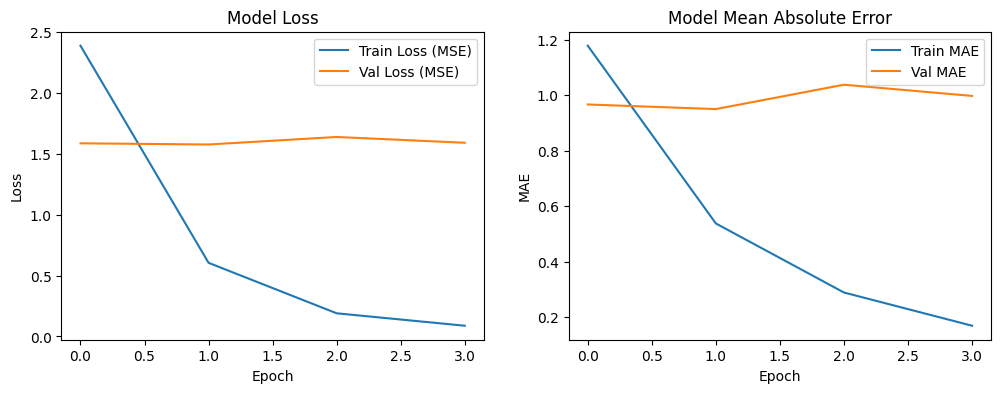


Generating recommendations for Customer:
Original ID: 236dd1945ca598f93d5228dcd8023f4f
Predicting scores for unseen products...
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step

🏆 --- Top 5 Recommended Products --- 🏆
1. Product ID: b48ac8fbef9f889656ccef21bd7ca87b | Predicted Rating: 5.05 / 5.00
2. Product ID: 85fd14e978b92176dd210c046abc3540 | Predicted Rating: 5.01 / 5.00
3. Product ID: 3f55594c92f61283dd292a1e6f1c6427 | Predicted Rating: 4.98 / 5.00
4. Product ID: 96b0a882d11b17ce51238420ec63e3a1 | Predicted Rating: 4.97 / 5.00
5. Product ID: cd59f488cef311feb633141ad1e8563d | Predicted Rating: 4.96 / 5.00


In [6]:
import matplotlib.pyplot as plt

# 1. Plot the training and validation loss/MAE
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

# 2. Generating Recommendations for a specific user
# Let's pick a random encoded user from our test set
target_user_encoded = X_test_user[0]
original_user_id = user_encoder.inverse_transform([target_user_encoded])[0]

print(f"\nGenerating recommendations for Customer:")
print(f"Original ID: {original_user_id}")

# Get all unique products in the dataset
all_products = np.array(range(num_unique_products))

# Find the products this user has already bought
user_interacted_products = df[df['user_encoded'] == target_user_encoded]['product_encoded'].unique()

# Keep only the products they HAVE NOT bought yet
products_to_predict = np.setdiff1d(all_products, user_interacted_products)

# Create the input arrays for the model (User ID repeated, paired with every unseen product)
user_input_array = np.array([target_user_encoded] * len(products_to_predict))

# Make predictions!
print("Predicting scores for unseen products...")
predicted_scores = model.predict([user_input_array, products_to_predict], batch_size=1024).flatten()

# Get the indices of the top 5 highest predicted scores
top_5_indices = predicted_scores.argsort()[-5:][::-1]

# Get the encoded product IDs and their predicted scores
top_5_product_encoded = products_to_predict[top_5_indices]
top_5_predicted_scores = predicted_scores[top_5_indices]

# Decode the product IDs back to their original string format
top_5_product_original = product_encoder.inverse_transform(top_5_product_encoded)

print("\n🏆 --- Top 5 Recommended Products --- 🏆")
for i in range(5):
    print(f"{i+1}. Product ID: {top_5_product_original[i]} | Predicted Rating: {top_5_predicted_scores[i]:.2f} / 5.00")